# 清洗数据
对数据集进行清洗操作并进行较为简单的可视化分析


# 可视化分析

   Row ID        Order ID Order Date  Ship Date       Ship Mode Customer ID  \
0       1  CA-2017-152156 2017-11-08 2017-11-11    Second Class    CG-12520   
1       2  CA-2017-152156 2017-11-08 2017-11-11    Second Class    CG-12520   
2       3  CA-2017-138688 2017-06-12 2017-06-16    Second Class    DV-13045   
3       4  US-2016-108966 2016-10-11 2016-10-18  Standard Class    SO-20335   
4       5  US-2016-108966 2016-10-11 2016-10-18  Standard Class    SO-20335   

     Customer Name    Segment        Country             City       State  \
0      Claire Gute   Consumer  United States        Henderson    Kentucky   
1      Claire Gute   Consumer  United States        Henderson    Kentucky   
2  Darrin Van Huff  Corporate  United States      Los Angeles  California   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale     Florida   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale     Florida   

   Postal Code Region       Product ID         Category Sub-Ca

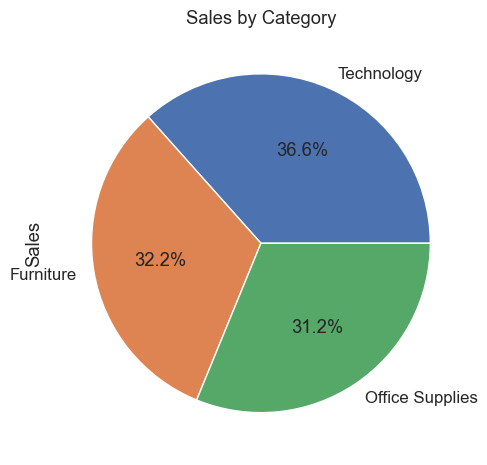

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8")
sns.set(font_scale=1.1)

# 统一的数据加载与基础清洗函数
def load_raw_data():
    file_path = r"D:\batest\train.csv"
    df_raw = pd.read_csv(file_path)

    # 基础类型转换
    df_raw["Order Date"] = pd.to_datetime(df_raw["Order Date"], format="%d/%m/%Y")
    df_raw["Ship Date"] = pd.to_datetime(df_raw["Ship Date"], format="%d/%m/%Y")

    return df_raw

df_raw = load_raw_data()

# 基本信息查看
print(df_raw.head())
print(df_raw.info())
print(df_raw.describe())

#看看哪类产品最赚钱
category_sales = df_raw.groupby('Category')['Sales'].sum().sort_values(ascending=False)
print(category_sales)

# 画个饼图直观一下
category_sales.plot(kind='pie', autopct='%1.1f%%', title='Sales by Category')
plt.show()




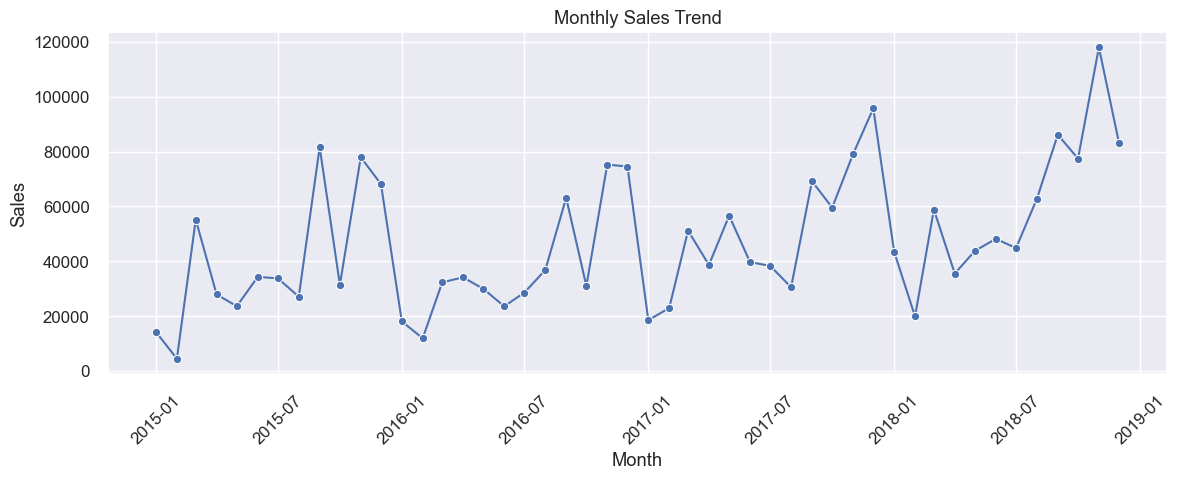

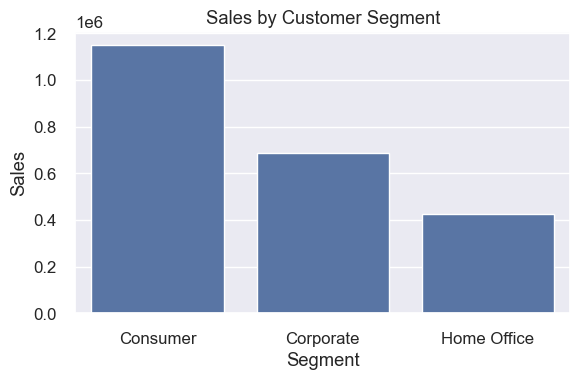

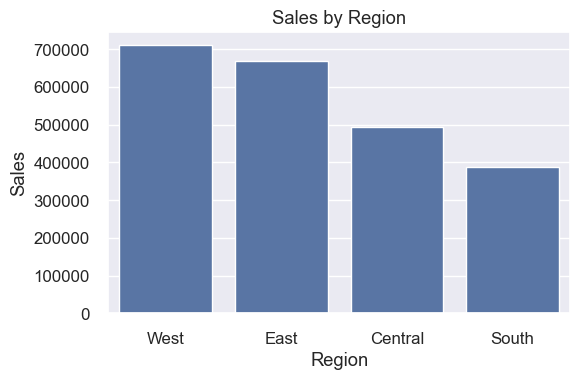

In [2]:
# 数据分析及运营 销售趋势与客户结构

df = df_raw.copy()
df["lead_time"] = (df["Ship Date"] - df["Order Date"]).dt.days
df["order_year"] = df["Order Date"].dt.year
df["order_month"] = df["Order Date"].dt.to_period("M")

# 1 按月汇总销售额
monthly_sales = df.groupby("order_month")["Sales"].sum().reset_index()
monthly_sales["order_month"] = monthly_sales["order_month"].dt.to_timestamp()

plt.figure(figsize=(12, 5))
sns.lineplot(data=monthly_sales, x="order_month", y="Sales", marker="o")
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#图中看出总体趋势是上升的，但是有波动，季节性不规则（节假日？大促？）
#样本偏小，只能预测短期

# 2 按客户类型销售额
segment_sales = df.groupby("Segment")["Sales"].sum().sort_values(ascending=False)

plt.figure(figsize=(6, 4))
sns.barplot(x=segment_sales.index, y=segment_sales.values)
plt.title("Sales by Customer Segment")
plt.xlabel("Segment")
plt.ylabel("Sales")
plt.tight_layout()
plt.show()
#B2C占比最大，其次是B2B

# 3 区域维度销售额
region_sales = df.groupby("Region")["Sales"].sum().sort_values(ascending=False)

plt.figure(figsize=(6, 4))
sns.barplot(x=region_sales.index, y=region_sales.values)
plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales")
plt.tight_layout()
plt.show()
#东部地区销售额最大，其次是西部和南部

# 进一步分析及预测

原始序列 ADF statistic: -4.416136761430769
原始序列 p-value: 0.00027791039276670623
一阶差分 ADF statistic: -8.727061830353266
一阶差分 p-value: 3.266917547279664e-14
下一期（月）预测销售额：
2018-12-01    83034.783012
Freq: MS, dtype: float64
预测置信区间：
             lower Sales    upper Sales
2018-12-01  35428.554411  130641.011613


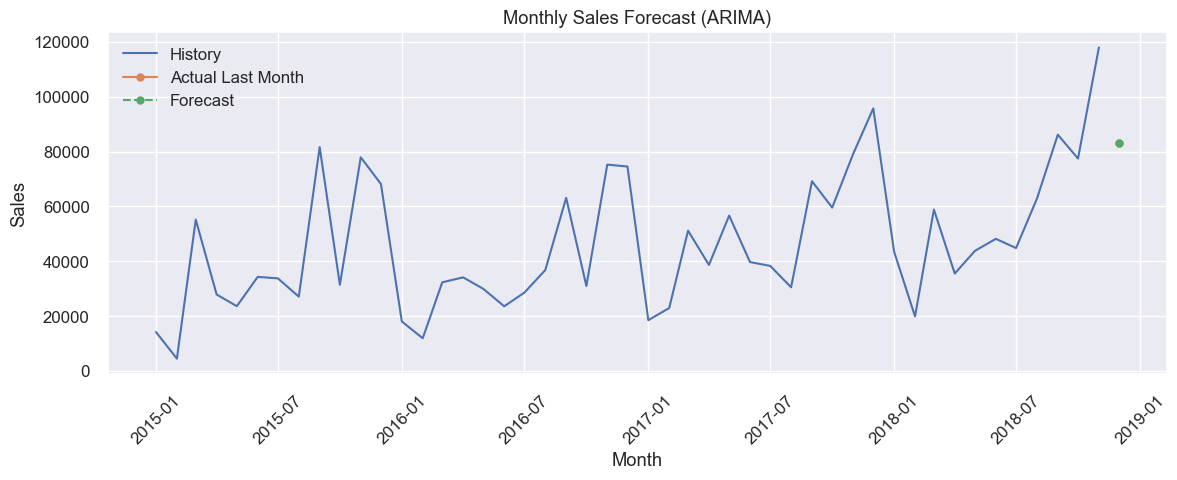

按 RFM 总分从高到低的前 10 个客户：
    Customer ID  Recency  Frequency   Monetary  R  F  M  RFM_Score
702    SM-20950       26         11  4464.8620  4  4  4         12
275    EP-13915       13         17  5478.0608  4  4  4         12
314    GZ-14470        8          9  4355.1500  4  4  4         12
387    JL-15835       22         10  9576.3430  4  4  4         12
31     AH-10210        7          9  4805.3440  4  4  4         12
618    RA-19915       13          9  4793.5430  4  4  4         12
558    ND-18370       28          9  4326.1390  4  4  4         12
35     AI-10855       14         10  4375.7860  4  4  4         12
623    RB-19465       10         12  4715.4660  4  4  4         12
278    ES-14080       29          9  4657.9240  4  4  4         12


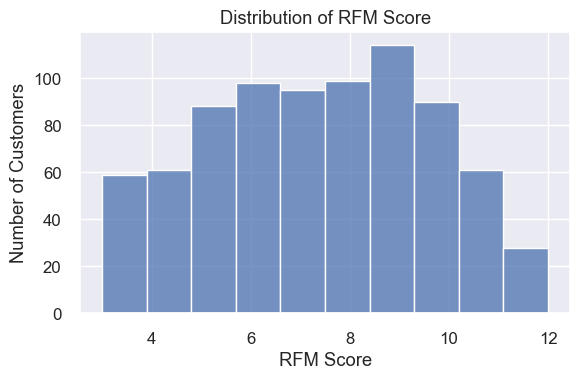

按 lift 排序的前 10 条规则：
                     antecedents                    consequents  \
2                   (Technology)   (Office Supplies, Furniture)   
1   (Office Supplies, Furniture)                   (Technology)   
0  (Technology, Office Supplies)                    (Furniture)   
3                    (Furniture)  (Technology, Office Supplies)   

   antecedent support  consequent support   support  confidence      lift  \
2            0.308614            0.191792  0.064608    0.209348  1.091538   
1            0.191792            0.308614  0.064608    0.336864  1.091538   
0            0.183056            0.350874  0.064608    0.352941  1.005893   
3            0.350874            0.183056  0.064608    0.184134  1.005893   

   representativity  leverage  conviction  zhangs_metric   jaccard  certainty  \
2               1.0  0.005418    1.022205       0.121295  0.148252   0.021723   
1               1.0  0.005418    1.042601       0.103763  0.148252   0.040860   
0              

c:\users\刘琼蔚\appdata\local\programs\python\python39\lib\site-packages\mlxtend\frequent_patterns\fpcommon.py:161: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


In [3]:
_df = df_raw.copy()
_df["order_month"] = _df["Order Date"].dt.to_period("M")


from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from mlxtend.frequent_patterns import apriori, association_rules


# 1. 月度销售预测


monthly_sales = _df.groupby("order_month")["Sales"].sum().reset_index()
monthly_sales["order_month"] = monthly_sales["order_month"].dt.to_timestamp()

sales_ts = monthly_sales.set_index("order_month")["Sales"].asfreq("MS")

# ADF 检验原始序列
adf_result = adfuller(sales_ts.dropna())
print("原始序列 ADF statistic:", adf_result[0])
print("原始序列 p-value:", adf_result[1])

# 一阶差分后再检验
sales_diff = sales_ts.diff().dropna()
adf_result_diff = adfuller(sales_diff)
print("一阶差分 ADF statistic:", adf_result_diff[0])
print("一阶差分 p-value:", adf_result_diff[1])

# 做一个简单 ARIMA 预测
train = sales_ts.iloc[:-1]
test = sales_ts.iloc[-1:]

model = SARIMAX(train, order=(1, 1, 1), seasonal_order=(0, 0, 0, 0))
res = model.fit(disp=False)

forecast_steps = 1
fc = res.get_forecast(steps=forecast_steps)
fc_mean = fc.predicted_mean
fc_ci = fc.conf_int()

print("下一期（月）预测销售额：")
print(fc_mean)
print("预测置信区间：")
print(fc_ci)

# 可视化历史 + 实际最后一个月 + 预测值
plt.figure(figsize=(12, 5))
plt.plot(train.index, train.values, label="History")
plt.plot(test.index, test.values, label="Actual Last Month", marker="o")
future_index = pd.date_range(start=train.index[-1] + pd.offsets.MonthBegin(1),
                             periods=forecast_steps, freq="MS")
plt.plot(future_index, fc_mean.values, label="Forecast", marker="o", linestyle="--")
plt.title("Monthly Sales Forecast (ARIMA)")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# 2. RFM 客户分群

snapshot_date = _df["Order Date"].max() + pd.Timedelta(days=1)

rfm = _df.groupby("Customer ID").agg({
    "Order Date": lambda x: (snapshot_date - x.max()).days,  # R
    "Order ID": "nunique",                                   # F
    "Sales": "sum"                                          # M
}).reset_index()

rfm.rename(columns={"Order Date": "Recency",
                    "Order ID": "Frequency",
                    "Sales": "Monetary"}, inplace=True)

quantiles = rfm[["Recency", "Frequency", "Monetary"]].quantile([0.25, 0.5, 0.75]).to_dict()


def r_score(x):
    if x <= quantiles["Recency"][0.25]:
        return 4
    elif x <= quantiles["Recency"][0.5]:
        return 3
    elif x <= quantiles["Recency"][0.75]:
        return 2
    else:
        return 1


def fm_score(x, col):
    if x <= quantiles[col][0.25]:
        return 1
    elif x <= quantiles[col][0.5]:
        return 2
    elif x <= quantiles[col][0.75]:
        return 3
    else:
        return 4


rfm["R"] = rfm["Recency"].apply(r_score)
rfm["F"] = rfm["Frequency"].apply(lambda x: fm_score(x, "Frequency"))
rfm["M"] = rfm["Monetary"].apply(lambda x: fm_score(x, "Monetary"))
rfm["RFM_Score"] = rfm[["R", "F", "M"]].sum(axis=1)

print("按 RFM 总分从高到低的前 10 个客户：")
print(rfm.sort_values("RFM_Score", ascending=False).head(10))

plt.figure(figsize=(6, 4))
sns.histplot(rfm["RFM_Score"], bins=10, kde=False)
plt.title("Distribution of RFM Score")
plt.xlabel("RFM Score")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()


# 3. 购物篮关联规则


basket = (
    _df.groupby(["Order ID", "Category"])["Sales"]
       .sum()
       .unstack()
       .fillna(0)
)

basket_bool = (basket > 0).astype(int)

frequent_items = apriori(basket_bool, min_support=0.02, use_colnames=True)
rules = association_rules(frequent_items, metric="lift", min_threshold=1.0)

rules_sorted = rules.sort_values("lift", ascending=False)
print("按 lift 排序的前 10 条规则：")
print(rules_sorted.head(10))

furniture_rules = rules_sorted[rules_sorted["antecedents"].astype(str).str.contains("Furniture")]
print("与 Furniture 相关的规则：")
print(furniture_rules.head(10))

# 报告
## 一 项目概况
基于 Kaggle 办公用品电商数据（约 9,800 条订单明细，2015–2018 年，美国市场），从时间、客户和区域三个角度做销售与运营分析，并延伸到简单的预测和客户运营建议。技术上主要用 pandas 做清洗与聚合，用 matplotlib / seaborn 做可视化。

数据预处理方面，只做了必要的类型转换：把 Order Date、Ship Date 转成日期，保留一份仅做基础清洗的 df_raw，每个分析模块都从 df_raw.copy() 开始，避免互相影响。

## 二 主要发现
整体销售走势

2015–2018 年的月度销售额呈“波动中上升”的趋势，后两年的整体水平明显高于前两年。

每年都有 1–2 个明显高点，位置不完全重合，更像是被促销或集中采购拉动的高峰，而不是非常规则的季节性。

客户结构

三类客户中，Consumer 占比最高，是当前的收入基础；Corporate 次之，Home Office 体量较小。

说明业务以零散订单为主，B 端大客户有提升空间，可以通过报价、框架协议等方式重点突破。

区域分布

不同 Region 之间销售规模差异明显，1–2 个区域贡献了更大头的销售。

这些区域适合作为市场投放和渠道建设的优先战场，其它区域则更适合小规模试点和策略验证。

## 三 时间序列预测与客户运营
简单的月度销售预测

把订单按月聚合后，对月度销售额做了 ADF 检验，原始序列呈现明显趋势，一阶差分后更接近平稳。

在此基础上，用一个简单的 ARIMA(1,1,1) 模型做了 1 期（月度）预测，结果主要作为“参考基线”，适合做短期预算和人力排班上的粗略判断。

由于数据长度有限（约 4 年），我会在实际场景中把这个模型当作决策的一个参考信号，而不是唯一依据。

RFM 客户分群

以 Customer ID 为粒度计算 Recency / Frequency / Monetary，并用分位数打分，合成 RFM_Score。

高分客户往往最近有购买、下单频率高、累计金额也高，可以作为“重点价值客户”，适合差异化服务和定向营销；

部分消费金额不错但 Recency 偏长的客户处在“容易流失”的阶段，可以用优惠券或专属活动做唤回。

关联规则（购物篮分析）

以 Order ID 为购物篮，在 Category 维度上做了简单的关联规则挖掘。

能看到一些直观的共购关系（例如科技类和办公用品之间的搭配），可以为“猜你喜欢”、捆绑销售或货架摆放提供依据。

## 四 落地建议
投放：结合月度趋势，高销售区域 + 高峰月份是优先投放窗口；在 Consumer 这块可以通过大促和推荐位提升客单和复购，在 Corporate / Home Office 上尝试更精细的 KA 运营。

备货：围绕高峰月和高价值品类（例如科技类、部分家具）提前提升安全库存，对波动较大的品类缩短补货周期；对发货慢但销售不低的区域，评估前置仓或物流方案。

服务 / 客户运营：基于 RFM 分层，对高分客户提供更及时的售后和定向优惠，对即将流失客户设置挽回动作；结合关联规则，在下单流程中增加简单的“搭配推荐”，争取每单多带一两件相关商品。